# 00 · Setup and a first exact check

**Time:** 20–30 minutes. **Prerequisites:** basic Python.

This notebook checks your kernel and the arithmetic libraries used later in the
course. You do not need to understand MPFR or Arb yet. By the end you should be
able to restart your kernel, run every cell, and distinguish a printed decimal
approximation from an exact rational value.

Follow [the installation instructions](../README.md), then select
**Python (Validated Computing)**. In Jupyter use *Kernel → Restart Kernel and
Run All Cells*. In VS Code use *Restart*, followed by *Run All*.

## Google Colab setup — run this cell first

**Local Jupyter:** this cell skips Colab setup; use your installed course environment.

Use a **CPU Python runtime** (Python 3.12 or newer). Run the next cell and select
**vc_runtime.zip** from this edition when prompted. It loads the course helpers
and installs the arithmetic libraries. Repeat setup whenever you get a new runtime.
No Drive mounting or local Python installation is required.
Use this setup instead of the local installation and kernel-selection instructions
in the original course text.

Save a copy of this notebook in Drive, or download it after editing. Files created
by the project are under `/content/validated-course/build/certificates/`; download
those separately from Colab's Files panel. Runtime files are temporary.

Open other course notebooks using **File → Upload notebook**, choosing them from
the extracted course folder. Relative course links are intended for local Jupyter
and do not open sibling notebooks automatically in Colab. In labs, complete exercise
cells before running their diagnostics: `NotImplementedError` marks an unfinished task.


In [1]:
try:
    import google.colab
except ImportError:
    print("Local Jupyter: using the installed course environment.")
else:
    import hashlib
    from pathlib import Path
    import subprocess
    import sys
    from google.colab import files

    if sys.version_info < (3, 12):
        raise RuntimeError("This course needs a Python 3.12 or newer Colab runtime.")

    # Upload the small companion file supplied with the Colab course edition.
    expected_hash = '833652c4a440f1c3a22bc6e68c59d533b41e6f9f1ff0b4af226f8fbee2244c1a'
    runtime_zip = Path("/content") / ("vc-course-" + expected_hash + ".zip")
    if not runtime_zip.exists():
        print("Select vc_runtime.zip from the extracted Colab course folder.")
        uploaded = files.upload()
        if len(uploaded) != 1:
            raise ValueError("Upload only vc_runtime.zip, then run this cell again.")
        archive_bytes = next(iter(uploaded.values()))
        if hashlib.sha256(archive_bytes).hexdigest() != expected_hash:
            raise ValueError("Wrong vc_runtime.zip: use the one supplied with this notebook.")
        runtime_zip.write_bytes(archive_bytes)

    if hashlib.sha256(runtime_zip.read_bytes()).hexdigest() != expected_hash:
        raise ValueError("The cached vc archive has changed; start a fresh runtime.")

    # Keep Colab's existing NumPy and plotting stack when they satisfy these bounds.
    # Install MPFR/Arb bindings, not the full local Jupyter environment.
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "--quiet",
        'numpy>=1.26', 'matplotlib>=3.8', 'gmpy2==2.3.1', 'python-flint==0.9.0', 'jupytext>=1.16'
    ])
    import gmpy2
    import flint
    if gmpy2.version() != "2.3.1" or flint.__version__ != "0.9.0":
        raise RuntimeError("Old arithmetic libraries are still loaded. Restart the session and run setup first.")

    if str(runtime_zip) not in sys.path:
        sys.path.insert(0, str(runtime_zip))

    import vc
    if not vc.__file__.startswith(str(runtime_zip) + "/"):
        raise RuntimeError("Another vc copy is already loaded. Start a fresh runtime.")

    # Preserve the relative output paths used by the project notebooks.
    import os
    working_folder = Path("/content/validated-course") / 'notebooks'
    working_folder.mkdir(parents=True, exist_ok=True)
    os.chdir(working_folder)
    print("Course helpers ready:", vc.__version__)

Local Jupyter: using the installed course environment.


In [2]:
import sys
from fractions import Fraction
from vc.environment import report, require_binary64

require_binary64()
print("Interpreter:", sys.executable)
for name, value in report().items():
    print(f"{name}: {value}")

Interpreter: /home/beni/python/ValidatedCompCourse/.venv/bin/python
Python: 3.12.9
platform: Linux-6.11.0-29-generic-x86_64-with-glibc2.39
numpy: 2.5.3
matplotlib: 3.11.1
gmpy2: 2.3.1
python-flint: 0.9.0
jupytext: 1.19.5
ipykernel: 7.3.0
GMP: GMP 6.3.0
MPFR: MPFR 4.2.2
MPC: MPC 1.4.0
FLINT: 3.6.0


## EXPERIMENT · A decimal label and its stored value

`Fraction(1, 10)` means the exact mathematical rational. `Fraction.from_float`
recovers the exact rational represented by a Python float. These are different
questions; neither conversion changes what was originally stored.

In [3]:
intended = Fraction(1, 10)
stored = Fraction.from_float(0.1)
print("Intended:", intended)
print("Stored:  ", stored)
print("Error:   ", stored - intended)
assert stored != intended
assert Fraction(1, 10) + Fraction(2, 10) == Fraction(3, 10)

Intended: 1/10
Stored:   3602879701896397/36028797018963968
Error:    1/180143985094819840


## EXPERIMENT · Smoke checks for the later arithmetic stack

MPFR lets us choose directed rounding. We convert its endpoints back to exact
rationals before comparing them with $1/10$. This check is about this particular
input; the general inclusion argument will be developed in Lecture 05.
Scoped contexts restore the previous settings on exit.

In [4]:
import gmpy2

initial_precision = gmpy2.get_context().precision
with gmpy2.context(precision=80, round=gmpy2.RoundDown):
    lower = gmpy2.mpfr("0.1")
with gmpy2.context(precision=80, round=gmpy2.RoundUp):
    upper = gmpy2.mpfr("0.1")

def mpfr_as_fraction(value):
    n, d = value.as_integer_ratio()
    return Fraction(int(n), int(d))

assert mpfr_as_fraction(lower) <= intended <= mpfr_as_fraction(upper)
assert gmpy2.get_context().precision == initial_precision
print("MPFR directed-rounding check passed.")

MPFR directed-rounding check passed.


Arb returns a ball: a midpoint together with an error radius. The operations
below enclose the intended rational, rather than just producing many digits.
For this smoke check, compare the ball's exact midpoint and radius with an exact
FLINT rational. This avoids any implicit conversion of a rational into a ball
inside a containment predicate.

In [5]:
from flint import arb, fmpq, ctx

initial_arb_precision = ctx.prec
with ctx.workprec(100):
    third = arb(1) / arb(3)
    m, r = third.mid().fmpq(), third.rad().fmpq()
    assert m - r <= fmpq(1, 3) <= m + r
    print("A ball enclosing 1/3:", third)
assert ctx.prec == initial_arb_precision

A ball enclosing 1/3: [0.33333333333333333333333333333 +/- 3.47e-30]


## EXPERIMENT · Inline plotting

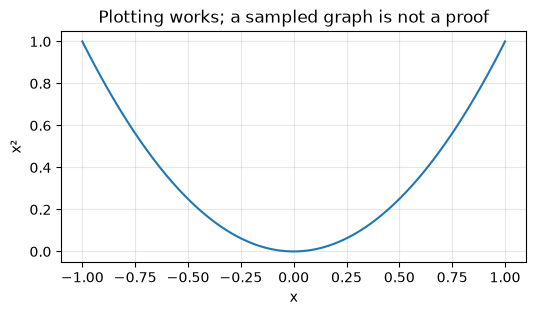

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

xs = np.linspace(-1, 1, 101)
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(xs, xs**2)
ax.set(xlabel="x", ylabel="x²", title="Plotting works; a sampled graph is not a proof")
ax.grid(alpha=0.3)
display(fig)
plt.close(fig)

## How to work through the course

- Lecture notebooks contain complete explanations and executable demonstrations.
- Lab notebooks contain tasks and **exercise** cells. Stubs deliberately raise
  `NotImplementedError` when called; replace them with your implementation.
- Run lab diagnostic cells after implementing their tasks. Submit code, outputs,
  and written interpretations. Passing a few tests is not a mathematical proof.
- Each notebook is independent. A name left over from a previous kernel session
  is not a dependency you may rely on.

**Checkpoint:** why would `arb(0.1)` and `arb("0.1")` describe different inputs?
We return to that question in Lecture 05.

**If something fails:** check the interpreter printed above, install from the
repository root, and restart the kernel. An import error usually means the
notebook is using a different environment. Report the first failing cell and
the version table when asking for help.

Continue with [Lecture 01](01_intro.ipynb).